In [4]:
!pip install langgraph langsmith

In [5]:
!pip install langchain langchain_groq langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.1/489.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.1
    Uninstalling langchain-core-1.2.1:
      Successfully uninstalled langchain-core-1.2.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-

In [ ]:
from google.colab import userdata
groq_api = userdata.get('GROQ_API')
langsmith_api=userdata.get('LANGSMITH_API')


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
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


In [27]:
import os
os.environ["LANGCHAIN_API"] = langsmith_api
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = "CHATBOTLANGCHAIN"

In [28]:
from langchain_groq import ChatGroq

In [29]:
llm =ChatGroq(groq_api_key=groq_api,model="llama-3.1-8b-instant")

## Start Building Chatbot Using Langgraph

In [30]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [31]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [32]:
graph_builder

In [33]:
def chatbot(state:State):
  return {"messages":llm.invoke(state["messages"])}

In [34]:
graph_builder.add_node("chatbot",chatbot)

In [35]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

In [36]:
graph = graph_builder.compile()

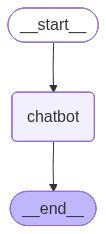

In [37]:
from IPython.display import Image, display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [38]:
while True:
  user_input = input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({"messages":("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant",value['messages'].content)

User: hello
dict_values([{'messages': AIMessage(content='Hello. Is there something I can help you with today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 36, 'total_tokens': 50, 'completion_time': 0.022248702, 'completion_tokens_details': None, 'prompt_time': 0.003141152, 'prompt_tokens_details': None, 'queue_time': 0.056124968, 'total_time': 0.025389854}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6c980774ec', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019b9e73-f999-79c3-a5c8-65e95f2d0db1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 14, 'total_tokens': 50})}])
content='Hello. Is there something I can help you with today?' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 36, 'total_tokens': 50, 'completion_time': 0.022248702, 'completion_tokens_

User: what is physics


dict_values([{'messages': AIMessage(content='Physics is a branch of science that studies the fundamental nature of the universe, from the smallest subatomic particles to the vastness of the cosmos. It seeks to understand the laws, principles, and behaviors that govern the physical world around us.\n\nPhysics is a broad and interdisciplinary field that encompasses various areas of study, including:\n\n1. **Mechanics**: The study of motion, forces, energy, and momentum.\n2. **Thermodynamics**: The study of heat, temperature, and the behavior of energy transfer.\n3. **Electromagnetism**: The study of electric and magnetic fields, light, and electromagnetic radiation.\n4. **Relativity**: The study of space, time, and gravity.\n5. **Quantum Mechanics**: The study of the behavior of matter and energy at the atomic and subatomic level.\n6. **Nuclear Physics**: The study of the behavior of atomic nuclei and nuclear reactions.\n7. **Condensed Matter Physics**: The study of the behavior of solid

User: q
Good Bye
